<a href="https://colab.research.google.com/github/bishaarabdi1/heart_disease-group-3/blob/bishar-model-training/machine-learning/heartdisease10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Connect Google Drive to Colab
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
# Load the heart disease dataset
df = pd.read_csv("heart_disease.csv")

In [ ]:
# Display the first 5 rows of the dataset
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0.0,6.0,0,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3.0,3.0,2,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2.0,7.0,1,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0.0,3.0,0,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0.0,3.0,0,0


In [ ]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
1019,60.072205,1,3,115.422056,181.768595,0,0,128.155858,1,1.001941,2,1.0,7.0,2,1
1020,70.928404,1,2,166.727221,244.993631,1,0,108.481311,0,0.698337,2,1.0,7.0,2,1
1021,57.332875,1,2,105.075177,233.146324,0,2,140.342007,0,1.519138,1,0.0,7.0,2,1
1022,40.881554,0,4,125.068578,154.370678,1,2,123.756294,0,1.936684,2,1.0,7.0,2,1
1023,46.863367,1,3,121.909777,291.175476,1,2,146.652276,1,1.913951,2,2.0,3.0,2,1


In [ ]:
# Show the number of rows and columns
df.shape

(1024, 15)

In [ ]:
# Display all column names
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'target_binary'],
      dtype='object')

In [ ]:
# Check the data type of each column
df.dtypes

,0
age,float64
sex,int64
cp,int64
trestbps,float64
chol,float64
fbs,int64
restecg,int64
thalach,float64
exang,int64
oldpeak,float64


In [ ]:
# This shows the number of rows, columns, column names, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1024 non-null   float64
 1   sex            1024 non-null   int64  
 2   cp             1024 non-null   int64  
 3   trestbps       1024 non-null   float64
 4   chol           1024 non-null   float64
 5   fbs            1024 non-null   int64  
 6   restecg        1024 non-null   int64  
 7   thalach        1024 non-null   float64
 8   exang          1024 non-null   int64  
 9   oldpeak        1024 non-null   float64
 10  slope          1024 non-null   int64  
 11  ca             1024 non-null   float64
 12  thal           1024 non-null   float64
 13  num            1024 non-null   int64  
 14  target_binary  1024 non-null   int64  
dtypes: float64(7), int64(8)
memory usage: 120.1 KB


In [ ]:
# Count missing values in each column
# This tells us how many empty values each column contains
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
# Count duplicated rows in the dataset
# This checks whether the same row appears more than once
df.duplicated().sum()

np.int64(0)

In [ ]:
# Display the data type of every column
# This helps us know how Python is interpreting each feature
df.dtypes

,0
age,float64
sex,int64
cp,int64
trestbps,float64
chol,float64
fbs,int64
restecg,int64
thalach,float64
exang,int64
oldpeak,float64


In [ ]:
# Display all column names in the dataset
# This helps us confirm the available features and target column
df.columns.tolist()

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'num',
 'target_binary']

this another to get all the columns

In [ ]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'target_binary'],
      dtype='object')

In [ ]:
# Calculate the percentage of each target class
# This gives us a clearer view of the class distribution
class_percentage = df["target_binary"].value_counts(normalize=True) * 100

# Display the percentages
class_percentage

,proportion
target_binary,
0,54.101562
1,45.898438


statistical summary.

DAY TWO EDA

In [ ]:
# Create a copy of the original dataset
# We will use new_df for EDA and data cleaning
new_df = df.copy()

In [ ]:
new_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
0,63.000000,1,1,145.000000,233.000000,1,2,150.000000,0,2.300000,3,0.0,6.0,0,0
1,67.000000,1,4,160.000000,286.000000,0,2,108.000000,1,1.500000,2,3.0,3.0,2,1
2,67.000000,1,4,120.000000,229.000000,0,2,129.000000,1,2.600000,2,2.0,7.0,1,1
3,37.000000,1,3,130.000000,250.000000,0,0,187.000000,0,3.500000,3,0.0,3.0,0,0
4,41.000000,0,2,130.000000,204.000000,0,2,172.000000,0,1.400000,1,0.0,3.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019,60.072205,1,3,115.422056,181.768595,0,0,128.155858,1,1.001941,2,1.0,7.0,2,1
1020,70.928404,1,2,166.727221,244.993631,1,0,108.481311,0,0.698337,2,1.0,7.0,2,1
1021,57.332875,1,2,105.075177,233.146324,0,2,140.342007,0,1.519138,1,0.0,7.0,2,1
1022,40.881554,0,4,125.068578,154.370678,1,2,123.756294,0,1.936684,2,1.0,7.0,2,1


In [ ]:
# This shows count, mean, standard deviation, minimum, and maximum values
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
count,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000
mean,54.532202,0.685547,3.149414,131.478621,246.965108,0.165039,1.001953,149.638107,0.345703,1.090142,1.619141,0.681641,4.701172,0.923828,0.458984
std,9.273400,0.464525,0.971812,17.506230,52.561237,0.371397,0.993624,23.480260,0.475829,1.072306,0.620176,0.947402,1.941107,1.070377,0.498558
min,18.000000,0.000000,1.000000,84.869643,100.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,48.193472,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.555581,0.000000,0.152062,1.000000,0.000000,3.000000,0.000000,0.000000
50%,55.000000,1.000000,3.000000,130.012111,244.996816,0.000000,1.000000,151.524700,0.000000,0.854977,2.000000,0.000000,3.000000,0.000000,0.000000
75%,61.196437,1.000000,4.000000,142.412148,280.232245,0.000000,2.000000,165.642437,1.000000,1.630471,2.000000,1.000000,7.000000,2.000000,1.000000
max,78.795030,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,227.196592,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000


In [ ]:
# Calculate the quartiles of age
Q1 = new_df["age"].quantile(0.25)
Q3 = new_df["age"].quantile(0.75)

# Calculate the Interquartile Range
IQR = Q3 - Q1

# Calculate the lower and upper boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Display the results
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 48.193471709653565
Q3: 61.19643708699776
IQR: 13.002965377344196
Lower Bound: 28.68902364363727
Upper Bound: 80.70088515301406


In [ ]:
# Find age values below the lower bound or above the upper bound
age_outliers = new_df[
    (new_df["age"] < lower_bound) |
    (new_df["age"] > upper_bound)
]

# Count the number of age outliers
age_outliers.shape[0]

3

In [ ]:
# Display the age values identified as outliers
age_outliers[["age"]]

,age
469,26.723614
516,21.483294
645,18.000000


In [ ]:
# List the numerical features
# These are the features where IQR outlier checking makes sense

numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# Check the number of outliers in each numerical feature
for column in numeric_features:
    Q1 = new_df[column].quantile(0.25)
    Q3 = new_df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = new_df[
        (new_df[column] < lower_bound) |
        (new_df[column] > upper_bound)
    ]

    print(column, ":", len(outliers), "outliers")

age : 3 outliers
trestbps : 14 outliers
chol : 14 outliers
thalach : 7 outliers
oldpeak : 25 outliers


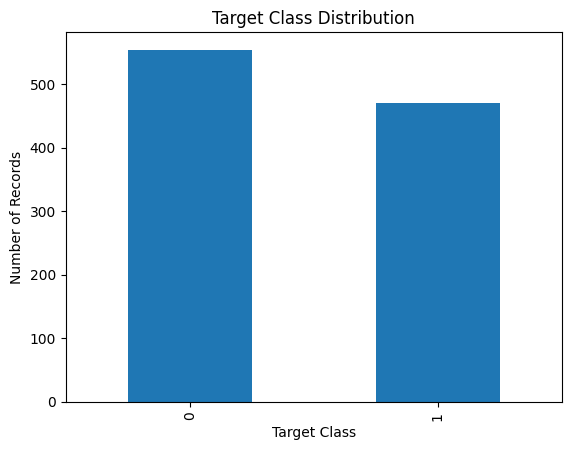

In [ ]:
# Show the distribution of the target classes
# This helps us visually understand the balance between class 0 and class 1

import matplotlib.pyplot as plt

new_df["target_binary"].value_counts().plot(kind="bar")

plt.title("Target Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Number of Records")

plt.show()

In [ ]:

# This helps us understand whether the target classes are balanced
class_balance = new_df["target_binary"].value_counts()

# Display the class counts
class_balance

,count
target_binary,
0,554
1,470


In [ ]:
# Check the unique values in each categorical feature
# This helps us understand which categories exist in the dataset

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

for column in categorical_features:
    print(column, ":", new_df[column].unique())

sex : [1 0]
cp : [1 4 3 2]
fbs : [1 0]
restecg : [2 0 1]
exang : [0 1]
slope : [3 2 1]
ca : [0. 3. 2. 1.]
thal : [6. 3. 7.]


In [ ]:
# Calculate the average value of each feature for each target class
# This helps us compare the features between class 0 and class 1

new_df.groupby("target_binary").mean()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
target_binary,,,,,,,,,,,,,,
0,52.673980,0.559567,2.774368,128.90465,242.101230,0.158845,0.826715,158.371049,0.16065,0.663377,1.422383,0.281588,3.828520,0.000000
1,56.722533,0.834043,3.591489,134.51262,252.698274,0.172340,1.208511,139.344384,0.56383,1.593179,1.851064,1.153191,5.729787,2.012766


In [ ]:
# Check whether any missing values remain after EDA
# A value greater than 0 means the column still contains missing data

new_df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
# Check for duplicate rows after EDA
# We want to confirm that no duplicate records remain

new_df.duplicated().sum()

np.int64(0)

## Baseline model & evaluation

In [ ]:
model_data = new_df.copy()

In [ ]:
# Separate the features from the target
X = model_data.drop(columns=["target_binary"])

In [ ]:
# y contains the value the model needs to predict
y = model_data["target_binary"]

In [ ]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Apply different preprocessing to different columns
from sklearn.compose import ColumnTransformer

# Convert categorical values into numerical values
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Combine preprocessing and model into one workflow
from sklearn.pipeline import Pipeline

# Metrics used to evaluate the model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

# Import Logistic Regression for the baseline model
from sklearn.linear_model import LogisticRegression

In [ ]:
# Numerical features
# These features contain continuous numerical values
numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# Categorical features
# These features represent categories
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal",
    "num"
]

TRAIN AND TEST SLPIT

In [ ]:
# Create X by removing the target column
# X contains all features used by the model
X = model_data.drop(columns=["target_binary"])

In [ ]:
# Create y using the target column
# y contains the value the model will predict
y = model_data["target_binary"]

In [ ]:
# Split the features and target into training and testing sets
# 80% will be used for training and 20% for testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Check the size of the training and testing data

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (819, 14)
X_test: (205, 14)
y_train: (819,)
y_test: (205,)


In [ ]:
# Create the preprocessing steps for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        # Scale numerical features so they have a similar range
        ("num", StandardScaler(), numeric_features),

        # Convert categorical features into numerical columns
        ("cat", OneHotEncoder(), categorical_features)
    ]
)

In [ ]:
# Create the baseline machine learning pipeline
# The pipeline first preprocesses the data, then trains Logistic Regression
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        # Logistic Regression is our baseline classification model
        ("classifier", LogisticRegression(
            random_state=42
        ))
    ]
)

In [ ]:

model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat', OneHotEncoder(),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal', 'num'])])),
                ('classifier', LogisticRegression(random_state=42))])

In [ ]:
y_pred= model.predict(X_test)

In [ ]:
y_pred

array([0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1])

In [ ]:

# evaluation
metrics_score= pd.DataFrame({
    "metrics": ["accuracy","precision","recall","f1"],
    "score": [
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred)
    ]
})
metrics_score

,metrics,score
0,accuracy,1.0
1,precision,1.0
2,recall,1.0
3,f1,1.0


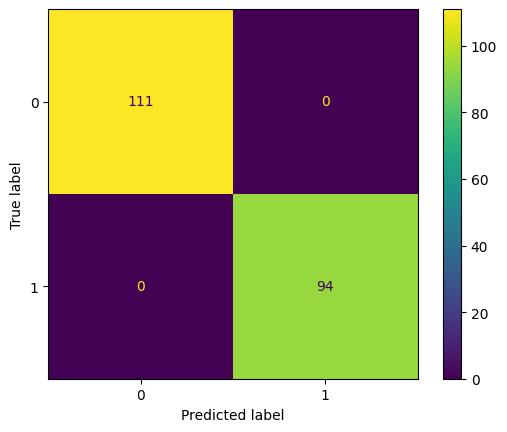

In [ ]:
# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

• Train at least two classification models.
WE AHVE DONE LOGISTICS REGRESSION

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Create the second classification model
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

In [ ]:
# Train the Decision Tree model
decision_tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat', OneHotEncoder(),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal', 'num'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [ ]:
# Make predictions using Decision Tree
y_pred_tree = decision_tree_model.predict(X_test)

In [ ]:
# Evaluate the Decision Tree model
tree_metrics = pd.DataFrame({
    "metrics": ["accuracy", "precision", "recall", "f1"],
    "score": [
        accuracy_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_tree)
    ]
})

tree_metrics

,metrics,score
0,accuracy,1.0
1,precision,1.0
2,recall,1.0
3,f1,1.0


In [ ]:
# Compare the performance of both classification models

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_tree)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_tree)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_tree)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_tree)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0


In [ ]:
# Select the model with the highest F1 score

best_model_name = comparison.loc[
    comparison["F1"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [ ]:
import joblib

In [ ]:
# Save the best performing model
joblib.dump(model, "best_model.joblib")

['best_model.joblib']